# CASALS L1B waveform-bin geolocation rule audit — revised notebook

This notebook audits whether non-`refh` waveform bins / detected peaks in CASALS L1B can be internally georeferenced.

The notebook deliberately separates three questions:

1. **Reference-bin closure**: does the L1B `refh` point correspond to a predictable RX waveform bin?
2. **Segment interpolation closure**: are `rwstart`, `refh`, and `rwstop` mutually consistent in 3D and in range-window fraction?
3. **Beam-angle propagation closure**: if we start from `refh` and propagate along `local_beam_azimuth/elevation`, which angle unit, direction sign, and range-bin spacing are consistent with the `rwstart`–`rwstop` segment?

The recommended geolocation rule is not chosen from one metric alone. The most robust internal rule is the one that closes `refh` against the waveform bin and closes the 3D `rwstart`–`rwstop` segment. Beam-angle propagation is then tested against that segment-derived geometry.

Official tutorial context: CASALS L1B contains `rx_waveform`, `refh`, `rwstart/rwstop`, `local_beam_azimuth/elevation`, `bin_size`, `sweep_num`, and `track_num`; the tutorial states that `refh` is the geolocated height of the maximum-amplitude RX waveform bin. It also defines a sweep as coincident pulses spanning available wavelengths/channels.


## 0. Configuration

Run the notebook from the repository root (`.../Research/CASALS`) or from `CASALS_L1B`. Adjust `H5_GLOBS` only if your H5 files are elsewhere.

The notebook writes CSV/Markdown outputs to `beam_geolocation_rule_audit_outputs_revised`.


In [2]:
from pathlib import Path
from typing import Callable
import glob
import json
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pyproj import Transformer
from tqdm.auto import tqdm

try:
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_SEED = 42
CHUNK_SIZE = 1024
MAX_PULSES_PER_FILE = None
SAMPLE_PULSES_FOR_PEAKS = 256
TOP_PEAKS_PER_WAVEFORM = 6
N_SWEEPS_FOR_PLANARITY = 24
MIN_TRACKS_PER_SWEEP = 200
PEAK_MIN_PROMINENCE_SIGMA = 5.0
PEAK_MIN_DISTANCE_BINS = 3
STRONG_PEAK_FRACTION = 0.5
PLANE_LINE_HALF_LENGTH_M = 1000.0
C_LIGHT = 299792458.0
GEODETIC_CRS = "EPSG:4979"
ECEF_CRS = "EPSG:4978"


In [3]:
# --- Path setup ---
PROJECT_ROOT = Path.cwd().resolve()

candidate_dirs = [PROJECT_ROOT, *PROJECT_ROOT.parents]
L1B_DIR = next(
    (
        p for p in candidate_dirs
        if p.name.lower() == "casals_l1b" and (p / "notebooks").exists()
    ),
    None,
)
if L1B_DIR is None:
    repo_candidate = PROJECT_ROOT / "CASALS_L1B"
    if repo_candidate.exists():
        L1B_DIR = repo_candidate.resolve()
    else:
        raise FileNotFoundError(f"Could not locate CASALS_L1B from {PROJECT_ROOT}")

H5_DIR = L1B_DIR / "casals_h5_downloads"
H5_GLOBS = [str(H5_DIR / "*.h5"), str(H5_DIR / "*.hdf5")]
OUT_DIR = L1B_DIR / "beam_geolocation_rule_audit_outputs_revised"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"L1B_DIR: {L1B_DIR}")
print(f"H5_DIR: {H5_DIR}")
print(f"OUT_DIR: {OUT_DIR}")


L1B_DIR: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B
H5_DIR: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads
OUT_DIR: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\beam_geolocation_rule_audit_outputs_revised


## 1. Geometry and H5 helper functions

All 3D closure tests are done in ECEF meters. This avoids local-projection distortions and lets us compare distances directly.


In [4]:
to_ecef = Transformer.from_crs(GEODETIC_CRS, ECEF_CRS, always_xy=True)
from_ecef = Transformer.from_crs(ECEF_CRS, GEODETIC_CRS, always_xy=True)


def resolve_h5_files(h5_globs: list[str]) -> list[Path]:
    paths: list[Path] = []
    seen: set[Path] = set()
    for pattern in h5_globs:
        for match in glob.glob(pattern):
            p = Path(match).expanduser().resolve()
            if p.is_file() and p.suffix.lower() in {".h5", ".hdf5"} and p not in seen:
                paths.append(p)
                seen.add(p)
    if not paths:
        raise FileNotFoundError(f"No H5 files found. Checked: {h5_globs}")
    return sorted(paths)


def dataset_path_map(h5: h5py.File) -> dict[str, str]:
    name_to_paths: dict[str, list[str]] = {}

    def visitor(name: str, obj: object) -> None:
        if isinstance(obj, h5py.Dataset):
            base = name.split("/")[-1]
            name_to_paths.setdefault(base, []).append("/" + name)

    h5.visititems(visitor)
    resolved: dict[str, str] = {}
    for base, paths in name_to_paths.items():
        if len(paths) == 1:
            resolved[base] = paths[0]
            continue
        root_match = [p for p in paths if p == f"/{base}"]
        if len(root_match) == 1:
            resolved[base] = root_match[0]
        else:
            raise ValueError(f"Ambiguous dataset basename {base}: {paths}")
    return resolved


REQUIRED_FIELDS = [
    "bin_size",
    "local_beam_azimuth",
    "local_beam_elevation",
    "refh",
    "refh_bounce_time_offset",
    "refh_latitude",
    "refh_longitude",
    "rwstart",
    "rwstart_bounce_time_offset",
    "rwstart_latitude",
    "rwstart_longitude",
    "rwstop",
    "rwstop_bounce_time_offset",
    "rwstop_latitude",
    "rwstop_longitude",
    "rx_bins",
    "rx_waveform",
]
OPTIONAL_FIELDS = [
    "refh_snr",
    "sweep_num",
    "track_num",
    "instrument_longitude",
    "instrument_latitude",
    "instrument_altitude",
]


def require_paths(h5: h5py.File) -> dict[str, str]:
    paths = dataset_path_map(h5)
    missing = [field for field in REQUIRED_FIELDS if field not in paths]
    if missing:
        raise KeyError(f"Missing required datasets: {missing}")
    return paths


def read_array(h5: h5py.File, paths: dict[str, str], name: str, idx=None, dtype=float, fill_value=np.nan) -> np.ndarray:
    if name not in paths:
        if idx is None:
            return np.asarray([], dtype=dtype)
        n = len(idx) if not isinstance(idx, slice) else 0
        return np.full(n, fill_value, dtype=dtype)
    arr = h5[paths[name]][idx] if idx is not None else h5[paths[name]][:]
    return np.asarray(arr, dtype=dtype)


def geodetic_to_ecef(lon: np.ndarray, lat: np.ndarray, h: np.ndarray) -> np.ndarray:
    x, y, z = to_ecef.transform(lon, lat, h)
    return np.stack([x, y, z], axis=-1)


def ecef_to_geodetic(xyz: np.ndarray) -> np.ndarray:
    lon, lat, h = from_ecef.transform(xyz[:, 0], xyz[:, 1], xyz[:, 2])
    return np.stack([lon, lat, h], axis=-1)


def enu_to_ecef_delta_matrix(lon_deg: np.ndarray, lat_deg: np.ndarray) -> np.ndarray:
    lon = np.deg2rad(np.asarray(lon_deg, dtype=float))
    lat = np.deg2rad(np.asarray(lat_deg, dtype=float))
    sin_lon = np.sin(lon)
    cos_lon = np.cos(lon)
    sin_lat = np.sin(lat)
    cos_lat = np.cos(lat)

    east = np.stack([-sin_lon, cos_lon, np.zeros_like(lon)], axis=-1)
    north = np.stack([-sin_lat * cos_lon, -sin_lat * sin_lon, cos_lat], axis=-1)
    up = np.stack([cos_lat * cos_lon, cos_lat * sin_lon, sin_lat], axis=-1)
    return np.stack([east, north, up], axis=-1)


def beam_unit_enu(az: np.ndarray, el: np.ndarray, angle_unit: str, vector_direction: str = "ref_to_sensor") -> np.ndarray:
    az = np.asarray(az, dtype=float)
    el = np.asarray(el, dtype=float)
    if angle_unit == "degree":
        az = np.deg2rad(az)
        el = np.deg2rad(el)
    elif angle_unit != "radian":
        raise ValueError(angle_unit)

    east = np.cos(el) * np.sin(az)
    north = np.cos(el) * np.cos(az)
    up = np.sin(el)
    vec = np.stack([east, north, up], axis=-1)
    norm = np.linalg.norm(vec, axis=-1)
    vec = vec / norm[:, None]
    if vector_direction == "sensor_to_ref":
        vec = -vec
    elif vector_direction != "ref_to_sensor":
        raise ValueError(vector_direction)
    return vec


def beam_unit_ecef(ref_lon: np.ndarray, ref_lat: np.ndarray, az: np.ndarray, el: np.ndarray, angle_unit: str, vector_direction: str) -> np.ndarray:
    v_enu = beam_unit_enu(az, el, angle_unit=angle_unit, vector_direction=vector_direction)
    rot = enu_to_ecef_delta_matrix(ref_lon, ref_lat)
    v_ecef = np.einsum("nij,nj->ni", rot, v_enu)
    return v_ecef / np.linalg.norm(v_ecef, axis=1)[:, None]


def rms_distance_m(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.linalg.norm(np.asarray(a, dtype=float) - np.asarray(b, dtype=float), axis=1)


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    an = np.linalg.norm(a, axis=1)
    bn = np.linalg.norm(b, axis=1)
    out = np.full(len(a), np.nan, dtype=float)
    valid = (an > 0) & (bn > 0)
    out[valid] = np.sum(a[valid] * b[valid], axis=1) / (an[valid] * bn[valid])
    return out


def infer_angle_unit_from_values(az: np.ndarray, el: np.ndarray) -> str:
    vals = np.concatenate([np.asarray(az, float).ravel(), np.asarray(el, float).ravel()])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return "unknown"
    p99 = float(np.nanpercentile(np.abs(vals), 99))
    if p99 <= 2 * np.pi + 0.1:
        return "radian"
    if p99 <= 361.0:
        return "degree"
    return "unknown"


def sample_indices(n_records: int, n_sample: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n = min(int(n_records), int(n_sample))
    return np.sort(rng.choice(int(n_records), size=n, replace=False))


## 2. Reference-bin and segment-closure metrics

A candidate rule is treated as internally plausible only if it passes two complementary checks:

- **Waveform-bin closure**: the predicted `refh` bin should be near the RX waveform maximum or at least near a strong local peak.
- **3D segment closure**: the geolocated `refh` point should lie on the ECEF line segment from `rwstart` to `rwstop`, and its geometric fractional coordinate should agree with the fractional bounce-time coordinate.

Important caution: the segment closure test is **not an external independent validation**. `rwstart`, `rwstop`, and `refh` are likely produced by the same L1B geolocation pipeline and the same beam geometry. Therefore, if they are all generated from the same underlying model, `refh` lying on the `rwstart`–`rwstop` segment may be expected. The value of this test is narrower but still useful: it confirms that the stored L1B fields are mutually self-consistent and that `rwstart/rwstop` can be used as the internal range-window coordinate frame for deriving bin locations.

The fraction-based rule is:

\[
 b_{refh} = \frac{t_{refh}-t_{rwstart}}{t_{rwstop}-t_{rwstart}}(N_{bins}-1)
\]

For a general waveform bin/peak `b`, the segment-interpolated point is:

\[
 P(b) = P_{rwstart} + \frac{b}{N_{bins}-1}(P_{rwstop}-P_{rwstart})
\]

This notebook distinguishes **internal L1B geometry consistency** from **external absolute accuracy**. External accuracy still requires comparison with independent reference data such as 3DEP, NEON, GNSS, or surveyed targets.


In [5]:
def strong_peak_mask(rx: np.ndarray, strong_fraction: float = STRONG_PEAK_FRACTION) -> tuple[np.ndarray, np.ndarray]:
    rx = np.asarray(rx)
    n_rows, n_bins = rx.shape
    argmax_bins = np.argmax(rx, axis=1)
    argmax_vals = rx[np.arange(n_rows), argmax_bins]
    threshold = strong_fraction * argmax_vals
    mask = np.zeros((n_rows, n_bins), dtype=bool)
    if n_bins == 1:
        mask[:, 0] = True
        return argmax_bins, mask
    mask[:, 0] = (rx[:, 0] >= rx[:, 1]) & (rx[:, 0] >= threshold)
    mask[:, -1] = (rx[:, -1] >= rx[:, -2]) & (rx[:, -1] >= threshold)
    mid = rx[:, 1:-1]
    mask[:, 1:-1] = (mid >= rx[:, :-2]) & (mid >= rx[:, 2:]) & (mid >= threshold[:, None])
    empty = ~mask.any(axis=1)
    if np.any(empty):
        mask[empty, argmax_bins[empty]] = True
    return argmax_bins, mask


def strong_peak_lookup_tables(mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    n_rows, n_bins = mask.shape
    cols = np.broadcast_to(np.arange(n_bins, dtype=np.int32), (n_rows, n_bins))
    left = np.where(mask, cols, -n_bins).astype(np.int32, copy=False)
    np.maximum.accumulate(left, axis=1, out=left)
    right = np.where(mask, cols, 2 * n_bins).astype(np.int32, copy=False)
    right = right[:, ::-1]
    np.minimum.accumulate(right, axis=1, out=right)
    right = right[:, ::-1]
    return left, right


def init_hist_state(n_bins: int) -> dict[str, object]:
    return {
        "n_total": 0,
        "n_valid": 0,
        "hist_argmax": np.zeros(n_bins, dtype=np.int64),
        "hist_strong": np.zeros(n_bins, dtype=np.int64),
    }


def hist_quantile(hist: np.ndarray, q: float) -> float:
    total = int(np.sum(hist))
    if total == 0:
        return np.nan
    target = q * (total - 1)
    csum = np.cumsum(hist)
    return float(np.searchsorted(csum, target, side="left"))


REFERENCE_BIN_MODELS: list[tuple[str, Callable[[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int], np.ndarray]]] = [
    ("argmax_rx_waveform", lambda ref, start, stop, bs, n_bins: np.full_like(ref, np.nan, dtype=float)),
    ("fraction_from_rwstart_to_rwstop", lambda ref, start, stop, bs, n_bins: np.divide(ref - start, stop - start, out=np.full_like(ref, np.nan, dtype=float), where=np.abs(stop - start) > 0) * (n_bins - 1)),
    ("reverse_fraction_from_rwstop", lambda ref, start, stop, bs, n_bins: np.divide(stop - ref, stop - start, out=np.full_like(ref, np.nan, dtype=float), where=np.abs(stop - start) > 0) * (n_bins - 1)),
    ("offset_over_bin_size", lambda ref, start, stop, bs, n_bins: (ref - start) / bs),
    ("offset_times_c_over_bin_size", lambda ref, start, stop, bs, n_bins: (ref - start) * C_LIGHT / bs),
    ("offset_times_c_over_2_over_bin_size", lambda ref, start, stop, bs, n_bins: (ref - start) * C_LIGHT / 2.0 / bs),
]


def reference_model_predictions(ref: np.ndarray, start: np.ndarray, stop: np.ndarray, bs: np.ndarray, n_bins: int, argmax_bins: np.ndarray) -> dict[str, np.ndarray]:
    out: dict[str, np.ndarray] = {}
    for name, fn in REFERENCE_BIN_MODELS:
        if name == "argmax_rx_waveform":
            out[name] = np.asarray(argmax_bins, dtype=float)
        else:
            with np.errstate(divide="ignore", invalid="ignore"):
                out[name] = np.asarray(fn(ref, start, stop, bs, n_bins), dtype=float)
    return out


def classify_reference_closure(valid_fraction: float, median_strong: float, p90_strong: float, median_argmax: float, p90_argmax: float) -> str:
    if valid_fraction >= 0.999 and median_strong <= 1 and p90_strong <= 3 and median_argmax <= 1 and p90_argmax <= 3:
        return "strong_reference_bin_closure"
    if valid_fraction >= 0.99 and median_strong <= 5 and p90_strong <= 25:
        return "moderate_reference_bin_closure"
    return "weak_reference_bin_closure"


def classify_segment_closure(median_dist_m: float, p90_dist_m: float, median_tdiff: float, p90_tdiff: float, off_fraction: float) -> str:
    if median_dist_m <= 0.01 and p90_dist_m <= 0.05 and median_tdiff <= 1e-4 and p90_tdiff <= 1e-4 and off_fraction <= 1e-6:
        return "strong_segment_closure"
    if median_dist_m <= 0.10 and p90_dist_m <= 0.50 and median_tdiff <= 1e-3 and p90_tdiff <= 1e-3 and off_fraction <= 1e-4:
        return "moderate_segment_closure"
    return "weak_segment_closure"


def stream_reference_and_segment_closure(h5: h5py.File, paths: dict[str, str], h5_path: Path, n_take: int, chunk_size: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rx_ds = h5[paths["rx_waveform"]]
    n_records, n_bins = rx_ds.shape
    states = {name: init_hist_state(n_bins) for name, _ in REFERENCE_BIN_MODELS}

    endpoint_dist_parts: list[np.ndarray] = []
    tdiff_parts: list[np.ndarray] = []
    segment_spacing_parts: list[np.ndarray] = []
    bin_size_parts: list[np.ndarray] = []
    time_c_spacing_parts: list[np.ndarray] = []
    time_c_over_2_spacing_parts: list[np.ndarray] = []
    off_segment_count = 0
    total_count = 0

    starts = range(0, n_take, chunk_size)
    for start_i in tqdm(starts, desc=f"reference/segment closure: {h5_path.name}"):
        stop_i = min(n_take, start_i + chunk_size)
        sl = slice(start_i, stop_i)
        rx = np.asarray(rx_ds[sl, :], dtype=np.float32)
        argmax_bins, strong_mask = strong_peak_mask(rx)
        left_lookup, right_lookup = strong_peak_lookup_tables(strong_mask)

        ref_t = read_array(h5, paths, "refh_bounce_time_offset", sl)
        start_t = read_array(h5, paths, "rwstart_bounce_time_offset", sl)
        stop_t = read_array(h5, paths, "rwstop_bounce_time_offset", sl)
        bs = read_array(h5, paths, "bin_size", sl)

        pred = reference_model_predictions(ref_t, start_t, stop_t, bs, n_bins, argmax_bins)
        for model_name, pred_bins_float in pred.items():
            state = states[model_name]
            state["n_total"] += len(pred_bins_float)
            pred_round = np.rint(pred_bins_float)
            valid = np.isfinite(pred_round) & (pred_round >= 0) & (pred_round < n_bins)
            state["n_valid"] += int(valid.sum())
            if not np.any(valid):
                continue
            rows = np.flatnonzero(valid)
            pred_bins = pred_round[valid].astype(np.int32, copy=False)
            d_argmax = np.abs(pred_bins - argmax_bins[valid].astype(np.int32))
            left_dist = pred_bins - left_lookup[rows, pred_bins]
            right_dist = right_lookup[rows, pred_bins] - pred_bins
            d_strong = np.minimum(left_dist, right_dist).astype(np.int32, copy=False)
            state["hist_argmax"] += np.bincount(d_argmax, minlength=n_bins)[:n_bins]
            state["hist_strong"] += np.bincount(d_strong, minlength=n_bins)[:n_bins]

        p0 = geodetic_to_ecef(
            read_array(h5, paths, "rwstart_longitude", sl),
            read_array(h5, paths, "rwstart_latitude", sl),
            read_array(h5, paths, "rwstart", sl),
        )
        p1 = geodetic_to_ecef(
            read_array(h5, paths, "rwstop_longitude", sl),
            read_array(h5, paths, "rwstop_latitude", sl),
            read_array(h5, paths, "rwstop", sl),
        )
        pr = geodetic_to_ecef(
            read_array(h5, paths, "refh_longitude", sl),
            read_array(h5, paths, "refh_latitude", sl),
            read_array(h5, paths, "refh", sl),
        )
        v = p1 - p0
        vv = np.sum(v * v, axis=1)
        t_geom = np.divide(np.sum((pr - p0) * v, axis=1), vv, out=np.full(len(vv), np.nan), where=vv > 0)
        t_time = np.divide(ref_t - start_t, stop_t - start_t, out=np.full(len(vv), np.nan), where=np.abs(stop_t - start_t) > 0)
        proj = p0 + t_geom[:, None] * v
        endpoint_dist_parts.append(np.linalg.norm(pr - proj, axis=1).astype(np.float32))
        tdiff_parts.append(np.abs(t_geom - t_time).astype(np.float32))
        off_segment_count += int(np.sum((t_geom < 0.0) | (t_geom > 1.0)))
        total_count += len(t_geom)

        segment_spacing = np.linalg.norm(v, axis=1) / (n_bins - 1)
        segment_spacing_parts.append(segment_spacing.astype(np.float32))
        bin_size_parts.append(bs.astype(np.float32))
        time_c_spacing_parts.append(((stop_t - start_t) * C_LIGHT / (n_bins - 1)).astype(np.float32))
        time_c_over_2_spacing_parts.append(((stop_t - start_t) * C_LIGHT / 2.0 / (n_bins - 1)).astype(np.float32))

    ref_rows = []
    for model_name, state in states.items():
        valid_fraction = state["n_valid"] / state["n_total"] if state["n_total"] else np.nan
        median_argmax = hist_quantile(state["hist_argmax"], 0.50)
        p90_argmax = hist_quantile(state["hist_argmax"], 0.90)
        median_strong = hist_quantile(state["hist_strong"], 0.50)
        p90_strong = hist_quantile(state["hist_strong"], 0.90)
        ref_rows.append({
            "h5_file": str(h5_path),
            "candidate_model": model_name,
            "n_pulses_scored": int(state["n_total"]),
            "valid_fraction": float(valid_fraction),
            "median_abs_bin_diff_to_argmax": float(median_argmax),
            "p90_abs_bin_diff_to_argmax": float(p90_argmax),
            "median_abs_bin_diff_to_nearest_strong_peak": float(median_strong),
            "p90_abs_bin_diff_to_nearest_strong_peak": float(p90_strong),
        })
    reference_df = pd.DataFrame(ref_rows)
    reference_df["closure_quality"] = [
        classify_reference_closure(r.valid_fraction, r.median_abs_bin_diff_to_nearest_strong_peak, r.p90_abs_bin_diff_to_nearest_strong_peak,
                                   r.median_abs_bin_diff_to_argmax, r.p90_abs_bin_diff_to_argmax)
        for r in reference_df.itertuples(index=False)
    ]

    endpoint_dist = np.concatenate(endpoint_dist_parts) if endpoint_dist_parts else np.array([], dtype=np.float32)
    tdiff = np.concatenate(tdiff_parts) if tdiff_parts else np.array([], dtype=np.float32)
    endpoint_row = {
        "h5_file": str(h5_path),
        "n_pulses_scored": int(total_count),
        "median_refh_distance_to_segment_m": float(np.nanmedian(endpoint_dist)),
        "p90_refh_distance_to_segment_m": float(np.nanpercentile(endpoint_dist, 90)),
        "median_abs_t_geom_minus_t_time": float(np.nanmedian(tdiff)),
        "p90_abs_t_geom_minus_t_time": float(np.nanpercentile(tdiff, 90)),
        "off_segment_fraction": float(off_segment_count / total_count) if total_count else np.nan,
    }
    endpoint_row["segment_closure_quality"] = classify_segment_closure(
        endpoint_row["median_refh_distance_to_segment_m"],
        endpoint_row["p90_refh_distance_to_segment_m"],
        endpoint_row["median_abs_t_geom_minus_t_time"],
        endpoint_row["p90_abs_t_geom_minus_t_time"],
        endpoint_row["off_segment_fraction"],
    )
    segment_df = pd.DataFrame([endpoint_row])

    segment_spacing = np.concatenate(segment_spacing_parts) if segment_spacing_parts else np.array([], dtype=np.float32)
    bin_size = np.concatenate(bin_size_parts) if bin_size_parts else np.array([], dtype=np.float32)
    time_c_spacing = np.concatenate(time_c_spacing_parts) if time_c_spacing_parts else np.array([], dtype=np.float32)
    time_c_over_2_spacing = np.concatenate(time_c_over_2_spacing_parts) if time_c_over_2_spacing_parts else np.array([], dtype=np.float32)
    spacing_rows = []
    for name, values in [
        ("bin_size_as_m_per_bin", bin_size),
        ("segment_length_over_n_bins_minus_1", segment_spacing),
        ("bounce_time_delta_times_c_over_bins", time_c_spacing),
        ("bounce_time_delta_times_c_over_2_over_bins", time_c_over_2_spacing),
    ]:
        diff = values - segment_spacing
        spacing_rows.append({
            "h5_file": str(h5_path),
            "spacing_candidate": name,
            "median_spacing_m_per_bin": float(np.nanmedian(values)),
            "p90_spacing_m_per_bin": float(np.nanpercentile(values, 90)),
            "median_abs_diff_to_segment_spacing_m": float(np.nanmedian(np.abs(diff))),
            "p90_abs_diff_to_segment_spacing_m": float(np.nanpercentile(np.abs(diff), 90)),
            "median_ratio_to_segment_spacing": float(np.nanmedian(values / segment_spacing)),
        })
    spacing_df = pd.DataFrame(spacing_rows)
    return reference_df, segment_df, spacing_df


## 3. Peak-level beam-rule scoring

For sampled waveforms, the notebook detects strong RX peaks and georeferences each peak in two ways:

1. **Segment-derived point** using `rwstart`–`rwstop` interpolation. This is the internal reference once segment closure is proven.
2. **Beam-derived point** using `refh + beam_vector × delta_range`.

The candidate beam rules vary by:

- angle unit: `radian` or `degree`;
- direction sign: `sensor_to_ref` or `ref_to_sensor`;
- spacing interpretation: `bin_size_as_m_per_bin`, `segment_length_over_n_bins_minus_1`, `bin_size_as_seconds_times_c`, `bin_size_as_seconds_two_way_c_over_2`.

`segment_length_over_n_bins_minus_1` is included as a diagnostic upper-bound closure because it uses the `rwstart`–`rwstop` segment length directly. It should not replace segment interpolation as the recommended product rule, but it is useful for validating beam direction and angle unit.


In [6]:
def safe_find_peaks_1d(y: np.ndarray, top_k: int) -> tuple[np.ndarray, np.ndarray]:
    y = np.asarray(y, dtype=float)
    if HAS_SCIPY:
        edge = max(20, int(0.1 * len(y)))
        bg = np.concatenate([y[:edge], y[-edge:]])
        med = float(np.nanmedian(bg))
        mad = float(np.nanmedian(np.abs(bg - med)))
        sigma = 1.4826 * mad if mad > 0 else float(np.nanstd(bg))
        prominence = PEAK_MIN_PROMINENCE_SIGMA * sigma if np.isfinite(sigma) and sigma > 0 else None
        peaks, _ = find_peaks(y, prominence=prominence, distance=PEAK_MIN_DISTANCE_BINS)
        if peaks.size == 0:
            peaks, _ = find_peaks(y, distance=PEAK_MIN_DISTANCE_BINS)
    else:
        peaks = np.where((y[1:-1] >= y[:-2]) & (y[1:-1] >= y[2:]))[0] + 1
    if peaks.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)
    strengths = y[peaks]
    order = np.argsort(strengths)[::-1][:top_k]
    return peaks[order], strengths[order]


def predict_refh_bin_fraction(ref_t: np.ndarray, start_t: np.ndarray, stop_t: np.ndarray, n_bins: int) -> np.ndarray:
    return np.divide(ref_t - start_t, stop_t - start_t, out=np.full_like(ref_t, np.nan, dtype=float), where=np.abs(stop_t - start_t) > 0) * (n_bins - 1)


def derive_peak_rows(h5: h5py.File, paths: dict[str, str], h5_path: Path, sample_pulses: int, top_peaks_per_waveform: int, seed: int) -> pd.DataFrame:
    rx_ds = h5[paths["rx_waveform"]]
    n_records, n_bins = rx_ds.shape
    idx = sample_indices(n_records, sample_pulses, seed)
    rx = np.asarray(rx_ds[idx, :], dtype=np.float32)
    argmax_bins = np.argmax(rx, axis=1)

    ref_t = read_array(h5, paths, "refh_bounce_time_offset", idx)
    start_t = read_array(h5, paths, "rwstart_bounce_time_offset", idx)
    stop_t = read_array(h5, paths, "rwstop_bounce_time_offset", idx)
    pred_ref_bin = predict_refh_bin_fraction(ref_t, start_t, stop_t, n_bins)

    ref_lon = read_array(h5, paths, "refh_longitude", idx)
    ref_lat = read_array(h5, paths, "refh_latitude", idx)
    ref_h = read_array(h5, paths, "refh", idx)
    rwstart_lon = read_array(h5, paths, "rwstart_longitude", idx)
    rwstart_lat = read_array(h5, paths, "rwstart_latitude", idx)
    rwstart_h = read_array(h5, paths, "rwstart", idx)
    rwstop_lon = read_array(h5, paths, "rwstop_longitude", idx)
    rwstop_lat = read_array(h5, paths, "rwstop_latitude", idx)
    rwstop_h = read_array(h5, paths, "rwstop", idx)
    az = read_array(h5, paths, "local_beam_azimuth", idx)
    el = read_array(h5, paths, "local_beam_elevation", idx)
    bs = read_array(h5, paths, "bin_size", idx)

    optional = {}
    for field in OPTIONAL_FIELDS:
        if field in paths:
            optional[field] = read_array(h5, paths, field, idx)
        else:
            optional[field] = np.full(len(idx), np.nan)

    p0 = geodetic_to_ecef(rwstart_lon, rwstart_lat, rwstart_h)
    p1 = geodetic_to_ecef(rwstop_lon, rwstop_lat, rwstop_h)
    segment_spacing = np.linalg.norm(p1 - p0, axis=1) / (n_bins - 1)

    rows: list[dict[str, object]] = []
    for local_i in tqdm(range(len(idx)), desc=f"sample peaks: {h5_path.name}"):
        peaks, strengths = safe_find_peaks_1d(rx[local_i], top_k=top_peaks_per_waveform)
        for rank, (peak_bin, peak_amp) in enumerate(zip(peaks, strengths), start=1):
            t_peak = float(peak_bin) / float(n_bins - 1)
            seg_xyz = p0[local_i] + t_peak * (p1[local_i] - p0[local_i])
            rows.append({
                "h5_file": str(h5_path),
                "source_pulse_index": int(idx[local_i]),
                "peak_rank_by_amplitude": int(rank),
                "peak_bin": int(peak_bin),
                "peak_amp": float(peak_amp),
                "argmax_bin": int(argmax_bins[local_i]),
                "predicted_refh_bin": float(pred_ref_bin[local_i]),
                "n_rx_bins": int(n_bins),
                "t_peak": t_peak,
                "ref_lon": float(ref_lon[local_i]),
                "ref_lat": float(ref_lat[local_i]),
                "ref_h": float(ref_h[local_i]),
                "rwstart_lon": float(rwstart_lon[local_i]),
                "rwstart_lat": float(rwstart_lat[local_i]),
                "rwstart_h": float(rwstart_h[local_i]),
                "rwstop_lon": float(rwstop_lon[local_i]),
                "rwstop_lat": float(rwstop_lat[local_i]),
                "rwstop_h": float(rwstop_h[local_i]),
                "local_beam_azimuth": float(az[local_i]),
                "local_beam_elevation": float(el[local_i]),
                "bin_size": float(bs[local_i]),
                "segment_spacing_m_per_bin": float(segment_spacing[local_i]),
                "segment_ecef_x": float(seg_xyz[0]),
                "segment_ecef_y": float(seg_xyz[1]),
                "segment_ecef_z": float(seg_xyz[2]),
                "refh_snr": float(optional["refh_snr"][local_i]) if np.isfinite(optional["refh_snr"][local_i]) else np.nan,
                "sweep_num": int(optional["sweep_num"][local_i]) if np.isfinite(optional["sweep_num"][local_i]) else np.nan,
                "track_num": int(optional["track_num"][local_i]) if np.isfinite(optional["track_num"][local_i]) else np.nan,
            })
    return pd.DataFrame(rows)


def spacing_values(rows: pd.DataFrame, interpretation: str) -> np.ndarray:
    if interpretation == "bin_size_as_m_per_bin":
        return rows["bin_size"].to_numpy(dtype=float)
    if interpretation == "segment_length_over_n_bins_minus_1":
        return rows["segment_spacing_m_per_bin"].to_numpy(dtype=float)
    if interpretation == "bin_size_as_seconds_times_c":
        return rows["bin_size"].to_numpy(dtype=float) * C_LIGHT
    if interpretation == "bin_size_as_seconds_two_way_c_over_2":
        return rows["bin_size"].to_numpy(dtype=float) * C_LIGHT / 2.0
    raise ValueError(interpretation)


def classify_beam_agreement(median_m: float, p90_m: float) -> str:
    if median_m <= 1.0 and p90_m <= 5.0:
        return "strong_beam_segment_agreement"
    if median_m <= 5.0 and p90_m <= 20.0:
        return "moderate_beam_segment_agreement"
    return "weak_beam_segment_agreement"


def classify_refh_return_error(median_m: float, p90_m: float) -> str:
    if median_m <= 0.25 and p90_m <= 1.0:
        return "strong_refh_return_closure"
    if median_m <= 1.0 and p90_m <= 5.0:
        return "moderate_refh_return_closure"
    return "weak_refh_return_closure"


def classify_direction_consistency(median_cos: float, p10_cos: float) -> str:
    if median_cos >= 0.99 and p10_cos >= 0.95:
        return "strong_direction_consistency"
    if median_cos >= 0.95 and p10_cos >= 0.80:
        return "moderate_direction_consistency"
    return "weak_direction_consistency"


def score_beam_rules(peak_df: pd.DataFrame) -> pd.DataFrame:
    if peak_df.empty:
        return pd.DataFrame()

    rows = peak_df.copy()
    ref_xyz = geodetic_to_ecef(rows["ref_lon"].to_numpy(), rows["ref_lat"].to_numpy(), rows["ref_h"].to_numpy())
    seg_xyz = rows[["segment_ecef_x", "segment_ecef_y", "segment_ecef_z"]].to_numpy(dtype=float)
    seg_delta = seg_xyz - ref_xyz

    unique = rows.drop_duplicates("source_pulse_index").copy()
    unique_ref_xyz = geodetic_to_ecef(unique["ref_lon"].to_numpy(), unique["ref_lat"].to_numpy(), unique["ref_h"].to_numpy())

    out_rows = []
    spacing_interps = [
        "bin_size_as_m_per_bin",
        "segment_length_over_n_bins_minus_1",
        "bin_size_as_seconds_times_c",
        "bin_size_as_seconds_two_way_c_over_2",
    ]
    for spacing_name in spacing_interps:
        spacing = spacing_values(rows, spacing_name)
        unique_spacing = spacing_values(unique, spacing_name)
        for angle_unit in ["radian", "degree"]:
            for vector_direction in ["sensor_to_ref", "ref_to_sensor"]:
                v_ecef = beam_unit_ecef(
                    rows["ref_lon"].to_numpy(),
                    rows["ref_lat"].to_numpy(),
                    rows["local_beam_azimuth"].to_numpy(),
                    rows["local_beam_elevation"].to_numpy(),
                    angle_unit=angle_unit,
                    vector_direction=vector_direction,
                )
                delta_bins = rows["peak_bin"].to_numpy(dtype=float) - rows["predicted_refh_bin"].to_numpy(dtype=float)
                delta_range_m = delta_bins * spacing
                beam_xyz = ref_xyz + delta_range_m[:, None] * v_ecef
                disagreement = rms_distance_m(beam_xyz, seg_xyz)
                direction_cos = cosine_similarity(delta_range_m[:, None] * v_ecef, seg_delta)

                # Refh closure using argmax bin. This is mostly a sanity check because refh should be near argmax.
                unique_v = beam_unit_ecef(
                    unique["ref_lon"].to_numpy(),
                    unique["ref_lat"].to_numpy(),
                    unique["local_beam_azimuth"].to_numpy(),
                    unique["local_beam_elevation"].to_numpy(),
                    angle_unit=angle_unit,
                    vector_direction=vector_direction,
                )
                unique_delta_bins = unique["argmax_bin"].to_numpy(dtype=float) - unique["predicted_refh_bin"].to_numpy(dtype=float)
                unique_delta_range_m = unique_delta_bins * unique_spacing
                argmax_beam_xyz = unique_ref_xyz + unique_delta_range_m[:, None] * unique_v
                refh_return_error = rms_distance_m(argmax_beam_xyz, unique_ref_xyz)

                finite_cos = direction_cos[np.isfinite(direction_cos)]
                median_cos = float(np.nanmedian(finite_cos)) if finite_cos.size else np.nan
                p10_cos = float(np.nanpercentile(finite_cos, 10)) if finite_cos.size else np.nan
                median_dis = float(np.nanmedian(disagreement))
                p90_dis = float(np.nanpercentile(disagreement, 90))
                median_refh = float(np.nanmedian(refh_return_error))
                p90_refh = float(np.nanpercentile(refh_return_error, 90))
                rule_key = f"{angle_unit}|{spacing_name}|{vector_direction}"
                out_rows.append({
                    "h5_file": rows["h5_file"].iloc[0],
                    "beam_rule_key": rule_key,
                    "angle_unit": angle_unit,
                    "range_spacing_interpretation": spacing_name,
                    "beam_vector_direction": vector_direction,
                    "n_peak_rows": int(len(rows)),
                    "n_refh_return_rows": int(len(unique)),
                    "median_beam_vs_segment_disagreement_m": median_dis,
                    "p90_beam_vs_segment_disagreement_m": p90_dis,
                    "median_refh_return_error_m": median_refh,
                    "p90_refh_return_error_m": p90_refh,
                    "median_direction_cosine": median_cos,
                    "p10_direction_cosine": p10_cos,
                    "beam_model_agreement_quality": classify_beam_agreement(median_dis, p90_dis),
                    "refh_return_closure_quality": classify_refh_return_error(median_refh, p90_refh),
                    "direction_consistency_quality": classify_direction_consistency(median_cos, p10_cos),
                })
    return pd.DataFrame(out_rows)


## 4. Sweep-level co-planarity diagnostic

Your co-planarity idea is implemented here.

For one sweep, we have up to 256 tracks. If those pulses are effectively coincident and form a cross-track scan fan, then their beam lines should be approximately contained in a common scan plane. The diagnostic below fits a plane to two points on each line and reports median/p90 perpendicular distance to that plane.

Important limitations:

- This is a **secondary physical-consistency check**, not the main geolocation proof.
- Co-planarity cannot determine the line direction sign, because reversing a line does not change the line.
- Co-planarity cannot determine range-bin spacing.
- Terrain shape is irrelevant if we fit the complete beam/range-window lines rather than only ground returns.


In [7]:
def fit_plane_pca(points: np.ndarray) -> dict[str, object]:
    pts = np.asarray(points, dtype=float)
    pts = pts[np.all(np.isfinite(pts), axis=1)]
    if len(pts) < 3:
        return {
            "plane_center_x": np.nan,
            "plane_center_y": np.nan,
            "plane_center_z": np.nan,
            "plane_normal_x": np.nan,
            "plane_normal_y": np.nan,
            "plane_normal_z": np.nan,
            "median_abs_plane_distance_m": np.nan,
            "p90_abs_plane_distance_m": np.nan,
            "rms_plane_distance_m": np.nan,
            "singular_value_ratio_s3_s2": np.nan,
        }
    center = pts.mean(axis=0)
    x = pts - center
    _, s, vt = np.linalg.svd(x, full_matrices=False)
    normal = vt[-1]
    dist = x @ normal
    ratio = float(s[-1] / s[-2]) if len(s) >= 2 and s[-2] > 0 else np.nan
    return {
        "plane_center_x": float(center[0]),
        "plane_center_y": float(center[1]),
        "plane_center_z": float(center[2]),
        "plane_normal_x": float(normal[0]),
        "plane_normal_y": float(normal[1]),
        "plane_normal_z": float(normal[2]),
        "median_abs_plane_distance_m": float(np.nanmedian(np.abs(dist))),
        "p90_abs_plane_distance_m": float(np.nanpercentile(np.abs(dist), 90)),
        "rms_plane_distance_m": float(np.sqrt(np.nanmean(dist ** 2))),
        "singular_value_ratio_s3_s2": ratio,
    }


def audit_sweep_planarity(h5: h5py.File, paths: dict[str, str], h5_path: Path, n_sweeps: int, min_tracks: int, seed: int) -> pd.DataFrame:
    if "sweep_num" not in paths or "track_num" not in paths:
        print(f"Skipping planarity for {h5_path.name}: sweep_num or track_num missing.")
        return pd.DataFrame()

    sweep_num = read_array(h5, paths, "sweep_num", None, dtype=np.int64)
    track_num = read_array(h5, paths, "track_num", None, dtype=np.int64)
    unique_sweeps, counts = np.unique(sweep_num, return_counts=True)
    eligible = unique_sweeps[counts >= min_tracks]
    if eligible.size == 0:
        print(f"Skipping planarity for {h5_path.name}: no sweeps with >= {min_tracks} tracks.")
        return pd.DataFrame()

    rng = np.random.default_rng(seed)
    selected = np.sort(rng.choice(eligible, size=min(n_sweeps, len(eligible)), replace=False))
    rows: list[dict[str, object]] = []

    for sweep in tqdm(selected, desc=f"sweep planarity: {h5_path.name}"):
        idx = np.flatnonzero(sweep_num == sweep)
        if len(idx) < min_tracks:
            continue
        tracks = track_num[idx]

        p0 = geodetic_to_ecef(
            read_array(h5, paths, "rwstart_longitude", idx),
            read_array(h5, paths, "rwstart_latitude", idx),
            read_array(h5, paths, "rwstart", idx),
        )
        p1 = geodetic_to_ecef(
            read_array(h5, paths, "rwstop_longitude", idx),
            read_array(h5, paths, "rwstop_latitude", idx),
            read_array(h5, paths, "rwstop", idx),
        )
        ref_lon = read_array(h5, paths, "refh_longitude", idx)
        ref_lat = read_array(h5, paths, "refh_latitude", idx)
        ref_h = read_array(h5, paths, "refh", idx)
        ref = geodetic_to_ecef(ref_lon, ref_lat, ref_h)
        az = read_array(h5, paths, "local_beam_azimuth", idx)
        el = read_array(h5, paths, "local_beam_elevation", idx)

        order = np.argsort(tracks)
        tracks = tracks[order]
        p0 = p0[order]
        p1 = p1[order]
        ref_lon = ref_lon[order]
        ref_lat = ref_lat[order]
        ref = ref[order]
        az = az[order]
        el = el[order]

        # Segment-endpoint scan plane.
        segment_points = np.vstack([p0, p1])
        plane = fit_plane_pca(segment_points)
        rows.append({
            "h5_file": str(h5_path),
            "sweep_num": int(sweep),
            "line_source": "rwstart_rwstop_segment_endpoints",
            "angle_unit": None,
            "n_tracks": int(len(idx)),
            "track_min": int(np.nanmin(tracks)),
            "track_max": int(np.nanmax(tracks)),
            **plane,
        })

        # Beam-angle scan plane. Sign does not matter for line planarity, so use ref_to_sensor consistently.
        for angle_unit in ["radian", "degree"]:
            v = beam_unit_ecef(ref_lon, ref_lat, az, el, angle_unit=angle_unit, vector_direction="ref_to_sensor")
            beam_points = np.vstack([ref - PLANE_LINE_HALF_LENGTH_M * v, ref + PLANE_LINE_HALF_LENGTH_M * v])
            plane = fit_plane_pca(beam_points)
            rows.append({
                "h5_file": str(h5_path),
                "sweep_num": int(sweep),
                "line_source": "beam_angle_lines",
                "angle_unit": angle_unit,
                "n_tracks": int(len(idx)),
                "track_min": int(np.nanmin(tracks)),
                "track_max": int(np.nanmax(tracks)),
                **plane,
            })
    return pd.DataFrame(rows)


## 5. Main audit functions

The final decision distinguishes:

- **Segment rule**: whether `rwstart/rwstop` interpolation can internally georeference arbitrary RX bins.
- **Beam rule**: whether `local_beam_azimuth/elevation` can reproduce the same bin locations when using the correct spacing convention.

For product generation, the notebook recommends segment interpolation if it is strongly supported, because it uses the two geolocated endpoints already provided by L1B and avoids ambiguity in angle convention and range-unit interpretation.


In [8]:
def serialize_attr_value(v: object) -> object:
    if isinstance(v, bytes):
        return v.decode("utf-8", errors="replace")
    if isinstance(v, np.generic):
        return v.item()
    if hasattr(v, "tolist"):
        return v.tolist()
    return v


def audit_one_file(h5_path: Path) -> dict[str, pd.DataFrame | dict[str, object]]:
    print("=" * 100)
    print(f"Auditing: {h5_path}")
    with h5py.File(h5_path, "r") as h5:
        paths = require_paths(h5)
        attrs = {str(k): serialize_attr_value(v) for k, v in h5.attrs.items()}
        rx_ds = h5[paths["rx_waveform"]]
        n_records, n_bins = rx_ds.shape
        n_take = min(n_records, MAX_PULSES_PER_FILE) if MAX_PULSES_PER_FILE is not None else n_records

        # Quick angle-unit inference from a small deterministic sample.
        idx = sample_indices(n_records, min(2048, n_records), RANDOM_SEED)
        az_sample = read_array(h5, paths, "local_beam_azimuth", idx)
        el_sample = read_array(h5, paths, "local_beam_elevation", idx)
        angle_unit_from_values = infer_angle_unit_from_values(az_sample, el_sample)

        file_meta = {
            "h5_file": str(h5_path),
            "n_pulses": int(n_records),
            "n_rx_bins": int(n_bins),
            "n_pulses_scored_for_stream_metrics": int(n_take),
            "angle_unit_inferred_from_values": angle_unit_from_values,
            "rx_bins_are_indices": bool(np.array_equal(read_array(h5, paths, "rx_bins", None), np.arange(n_bins))),
            "start_utca": attrs.get("start_utca"),
            "end_utca": attrs.get("end_utca"),
            "speed_of_light_attr": attrs.get("speed_of_light"),
            "sec_to_meters_attr": attrs.get("sec_to_meters"),
            "tdms_file": attrs.get("tdms_file"),
        }
        print(pd.Series(file_meta).to_string())

        reference_df, segment_df, spacing_df = stream_reference_and_segment_closure(
            h5=h5, paths=paths, h5_path=h5_path, n_take=n_take, chunk_size=CHUNK_SIZE
        )
        print("\nBest reference-bin models:")
        display(reference_df.sort_values([
            "valid_fraction",
            "median_abs_bin_diff_to_nearest_strong_peak",
            "p90_abs_bin_diff_to_nearest_strong_peak",
            "median_abs_bin_diff_to_argmax",
        ], ascending=[False, True, True, True]).head(6))
        print("\nSegment closure:")
        display(segment_df)
        print("\nSpacing diagnostics:")
        display(spacing_df)

        peak_df = derive_peak_rows(
            h5=h5,
            paths=paths,
            h5_path=h5_path,
            sample_pulses=SAMPLE_PULSES_FOR_PEAKS,
            top_peaks_per_waveform=TOP_PEAKS_PER_WAVEFORM,
            seed=RANDOM_SEED,
        )
        beam_scores_df = score_beam_rules(peak_df)
        print("\nBest beam rules:")
        display(beam_scores_df.sort_values([
            "median_beam_vs_segment_disagreement_m",
            "p90_beam_vs_segment_disagreement_m",
            "p90_refh_return_error_m",
            "median_direction_cosine",
        ], ascending=[True, True, True, False]).head(8))

        planarity_df = audit_sweep_planarity(
            h5=h5,
            paths=paths,
            h5_path=h5_path,
            n_sweeps=N_SWEEPS_FOR_PLANARITY,
            min_tracks=MIN_TRACKS_PER_SWEEP,
            seed=RANDOM_SEED,
        )
        if len(planarity_df):
            print("\nSweep planarity summary:")
            display(planarity_df.groupby(["line_source", "angle_unit"], dropna=False)[[
                "median_abs_plane_distance_m", "p90_abs_plane_distance_m", "rms_plane_distance_m", "singular_value_ratio_s3_s2"
            ]].median().reset_index())

    return {
        "file_meta": file_meta,
        "reference_df": reference_df,
        "segment_df": segment_df,
        "spacing_df": spacing_df,
        "peak_df": peak_df,
        "beam_scores_df": beam_scores_df,
        "planarity_df": planarity_df,
    }


def combine_audit_frames(audits: list[dict[str, object]], key: str) -> pd.DataFrame:
    frames = [a[key] for a in audits if isinstance(a.get(key), pd.DataFrame) and len(a[key])]  # type: ignore[index]
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def choose_best_reference(reference_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for h5_file, g in reference_df.groupby("h5_file"):
        eligible = g[g["candidate_model"] != "argmax_rx_waveform"].copy()
        if eligible.empty:
            eligible = g.copy()
        best = eligible.sort_values([
            "valid_fraction",
            "median_abs_bin_diff_to_nearest_strong_peak",
            "p90_abs_bin_diff_to_nearest_strong_peak",
            "median_abs_bin_diff_to_argmax",
        ], ascending=[False, True, True, True]).iloc[0].to_dict()
        rows.append(best)
    return pd.DataFrame(rows)


def choose_best_beam(beam_df: pd.DataFrame, spacing_filter: str | None = None) -> pd.DataFrame:
    rows = []
    for h5_file, g in beam_df.groupby("h5_file"):
        if spacing_filter is not None:
            g = g[g["range_spacing_interpretation"] == spacing_filter].copy()
        if g.empty:
            continue
        best = g.sort_values([
            "median_beam_vs_segment_disagreement_m",
            "p90_beam_vs_segment_disagreement_m",
            "p90_refh_return_error_m",
            "median_direction_cosine",
        ], ascending=[True, True, True, False]).iloc[0].to_dict()
        rows.append(best)
    return pd.DataFrame(rows)


def build_final_decision(file_meta_df: pd.DataFrame, best_reference_df: pd.DataFrame, segment_df: pd.DataFrame, best_beam_df: pd.DataFrame, best_stored_bin_size_beam_df: pd.DataFrame) -> pd.DataFrame:
    merged = (
        file_meta_df
        .merge(best_reference_df[["h5_file", "candidate_model", "closure_quality", "median_abs_bin_diff_to_argmax", "p90_abs_bin_diff_to_argmax", "median_abs_bin_diff_to_nearest_strong_peak", "p90_abs_bin_diff_to_nearest_strong_peak"]], on="h5_file", how="left")
        .merge(segment_df[["h5_file", "segment_closure_quality", "median_refh_distance_to_segment_m", "p90_refh_distance_to_segment_m", "median_abs_t_geom_minus_t_time", "p90_abs_t_geom_minus_t_time"]], on="h5_file", how="left")
        .merge(best_beam_df.add_prefix("best_beam__"), left_on="h5_file", right_on="best_beam__h5_file", how="left")
        .merge(best_stored_bin_size_beam_df.add_prefix("stored_bin_size_beam__"), left_on="h5_file", right_on="stored_bin_size_beam__h5_file", how="left")
    )
    rows = []
    for row in merged.to_dict(orient="records"):
        ref_strong = row.get("closure_quality") == "strong_reference_bin_closure"
        seg_strong = row.get("segment_closure_quality") == "strong_segment_closure"
        best_beam_strong = (
            row.get("best_beam__beam_model_agreement_quality") == "strong_beam_segment_agreement"
            and row.get("best_beam__direction_consistency_quality") == "strong_direction_consistency"
        )
        stored_bin_strong = (
            row.get("stored_bin_size_beam__beam_model_agreement_quality") == "strong_beam_segment_agreement"
            and row.get("stored_bin_size_beam__direction_consistency_quality") == "strong_direction_consistency"
        )

        if ref_strong and seg_strong:
            segment_status = "SEGMENT_INTERPOLATION_RULE_SUPPORTED"
            recommended_rule = "Use rwstart/rwstop ECEF segment interpolation for arbitrary RX bins."
        elif row.get("closure_quality") in {"strong_reference_bin_closure", "moderate_reference_bin_closure"} and row.get("segment_closure_quality") in {"strong_segment_closure", "moderate_segment_closure"}:
            segment_status = "SEGMENT_INTERPOLATION_RULE_LOW_CONFIDENCE"
            recommended_rule = "Segment interpolation is plausible but should be inspected before product use."
        else:
            segment_status = "SEGMENT_INTERPOLATION_RULE_NOT_CONFIRMED"
            recommended_rule = "Do not derive non-refh bin coordinates from L1B without further evidence."

        if best_beam_strong:
            beam_status = "BEAM_ANGLE_RULE_SUPPORTED_AGAINST_SEGMENT"
        elif row.get("best_beam__beam_model_agreement_quality") in {"strong_beam_segment_agreement", "moderate_beam_segment_agreement"}:
            beam_status = "BEAM_ANGLE_RULE_LOW_CONFIDENCE"
        else:
            beam_status = "BEAM_ANGLE_RULE_NOT_CONFIRMED"

        rows.append({
            "scope": "file",
            "h5_file": row["h5_file"],
            "segment_rule_status": segment_status,
            "beam_rule_status": beam_status,
            "recommended_bin_geolocation_rule": recommended_rule,
            "best_reference_bin_model": row.get("candidate_model"),
            "reference_closure_quality": row.get("closure_quality"),
            "segment_closure_quality": row.get("segment_closure_quality"),
            "best_beam_rule_key": row.get("best_beam__beam_rule_key"),
            "best_beam_median_error_m": row.get("best_beam__median_beam_vs_segment_disagreement_m"),
            "best_beam_p90_error_m": row.get("best_beam__p90_beam_vs_segment_disagreement_m"),
            "best_stored_bin_size_beam_rule_key": row.get("stored_bin_size_beam__beam_rule_key"),
            "stored_bin_size_beam_median_error_m": row.get("stored_bin_size_beam__median_beam_vs_segment_disagreement_m"),
            "stored_bin_size_beam_p90_error_m": row.get("stored_bin_size_beam__p90_beam_vs_segment_disagreement_m"),
            "stored_bin_size_beam_rule_is_strong": bool(stored_bin_strong),
            "angle_unit_inferred_from_values": row.get("angle_unit_inferred_from_values"),
        })

    file_df = pd.DataFrame(rows)
    all_segment_ok = len(file_df) > 0 and (file_df["segment_rule_status"] == "SEGMENT_INTERPOLATION_RULE_SUPPORTED").all()
    all_beam_ok = len(file_df) > 0 and (file_df["beam_rule_status"] == "BEAM_ANGLE_RULE_SUPPORTED_AGAINST_SEGMENT").all()
    stable_best_beam = file_df["best_beam_rule_key"].nunique(dropna=True) == 1 if len(file_df) else False
    stable_stored_beam = file_df["best_stored_bin_size_beam_rule_key"].nunique(dropna=True) == 1 if len(file_df) else False

    global_row = {
        "scope": "global",
        "h5_file": "__GLOBAL__",
        "segment_rule_status": "SEGMENT_INTERPOLATION_RULE_SUPPORTED" if all_segment_ok else "SEGMENT_INTERPOLATION_RULE_NOT_UNIFORMLY_CONFIRMED",
        "beam_rule_status": "BEAM_ANGLE_RULE_SUPPORTED_AGAINST_SEGMENT" if all_beam_ok and stable_best_beam else "BEAM_ANGLE_RULE_NOT_UNIFORMLY_CONFIRMED",
        "recommended_bin_geolocation_rule": "Use rwstart/rwstop ECEF segment interpolation for arbitrary RX bins." if all_segment_ok else "Inspect per-file results before deriving non-refh bin coordinates.",
        "best_reference_bin_model": None,
        "reference_closure_quality": None,
        "segment_closure_quality": None,
        "best_beam_rule_key": file_df["best_beam_rule_key"].iloc[0] if stable_best_beam and len(file_df) else None,
        "best_beam_median_error_m": None,
        "best_beam_p90_error_m": None,
        "best_stored_bin_size_beam_rule_key": file_df["best_stored_bin_size_beam_rule_key"].iloc[0] if stable_stored_beam and len(file_df) else None,
        "stored_bin_size_beam_median_error_m": None,
        "stored_bin_size_beam_p90_error_m": None,
        "stored_bin_size_beam_rule_is_strong": bool(file_df["stored_bin_size_beam_rule_is_strong"].all()) if len(file_df) else False,
        "angle_unit_inferred_from_values": None,
    }
    return pd.concat([file_df, pd.DataFrame([global_row])], ignore_index=True)


def write_markdown_summary(final_df: pd.DataFrame, out_path: Path) -> None:
    lines = ["# CASALS L1B geolocation rule audit — revised", ""]
    g = final_df[final_df["scope"] == "global"].iloc[0]
    lines += [
        "## Global decision",
        f"- Segment rule status: `{g['segment_rule_status']}`",
        f"- Beam rule status: `{g['beam_rule_status']}`",
        f"- Recommended bin geolocation rule: {g['recommended_bin_geolocation_rule']}",
        f"- Stable best beam rule key: `{g['best_beam_rule_key']}`",
        f"- Stable stored-bin-size beam rule key: `{g['best_stored_bin_size_beam_rule_key']}`",
        "",
        "## Per-file decisions",
    ]
    for _, row in final_df[final_df["scope"] == "file"].iterrows():
        lines += [
            f"### {Path(row['h5_file']).name}",
            f"- Segment rule: `{row['segment_rule_status']}`",
            f"- Beam rule: `{row['beam_rule_status']}`",
            f"- Best reference-bin model: `{row['best_reference_bin_model']}`",
            f"- Reference closure: `{row['reference_closure_quality']}`",
            f"- Segment closure: `{row['segment_closure_quality']}`",
            f"- Best beam rule: `{row['best_beam_rule_key']}`; median/p90 error = `{row['best_beam_median_error_m']}` / `{row['best_beam_p90_error_m']}` m",
            f"- Stored-bin-size beam rule: `{row['best_stored_bin_size_beam_rule_key']}`; median/p90 error = `{row['stored_bin_size_beam_median_error_m']}` / `{row['stored_bin_size_beam_p90_error_m']}` m",
            f"- Recommended rule: {row['recommended_bin_geolocation_rule']}",
            "",
        ]
    out_path.write_text("\n".join(lines), encoding="utf-8")


## 6. Run the audit

This is the main execution cell. It prints progress for each file, writes all output CSVs, and displays compact summaries.


In [ ]:
h5_files = resolve_h5_files(H5_GLOBS)
print(f"Found {len(h5_files)} H5 files:")
for p in h5_files:
    print(" -", p)

audits = [audit_one_file(p) for p in h5_files]

file_meta_df = pd.DataFrame([a["file_meta"] for a in audits])
reference_df = combine_audit_frames(audits, "reference_df")
segment_df = combine_audit_frames(audits, "segment_df")
spacing_df = combine_audit_frames(audits, "spacing_df")
peak_df = combine_audit_frames(audits, "peak_df")
beam_scores_df = combine_audit_frames(audits, "beam_scores_df")
planarity_df = combine_audit_frames(audits, "planarity_df")

best_reference_df = choose_best_reference(reference_df)
best_beam_df = choose_best_beam(beam_scores_df)
best_stored_bin_size_beam_df = choose_best_beam(beam_scores_df, spacing_filter="bin_size_as_m_per_bin")
final_df = build_final_decision(file_meta_df, best_reference_df, segment_df, best_beam_df, best_stored_bin_size_beam_df)

outputs = {
    "file_metadata_revised.csv": file_meta_df,
    "reference_bin_model_scores_revised.csv": reference_df,
    "best_reference_bin_model_revised.csv": best_reference_df,
    "segment_closure_revised.csv": segment_df,
    "spacing_diagnostics_revised.csv": spacing_df,
    "derived_peak_rows_revised.csv": peak_df,
    "beam_rule_scores_revised.csv": beam_scores_df,
    "best_beam_rule_revised.csv": best_beam_df,
    "best_stored_bin_size_beam_rule_revised.csv": best_stored_bin_size_beam_df,
    "sweep_planarity_revised.csv": planarity_df,
    "final_rule_decision_revised.csv": final_df,
}
for name, df in outputs.items():
    df.to_csv(OUT_DIR / name, index=False)
write_markdown_summary(final_df, OUT_DIR / "summary_revised.md")

print(f"\nWrote outputs to: {OUT_DIR}")
display(final_df)


Found 3 H5 files:
 - C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5
 - C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5
 - C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5
Auditing: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5
h5_file                               C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5
n_pulses                                                                                                                                                  3604480
n_rx_bins                                                                                                                                      

reference/segment closure: casals_l1b_20241112T165718_001_02.h5:   0%|          | 0/3520 [00:00<?, ?it/s]


Best reference-bin models:


,h5_file,candidate_model,n_pulses_scored,valid_fraction,median_abs_bin_diff_to_argmax,p90_abs_bin_diff_to_argmax,median_abs_bin_diff_to_nearest_strong_peak,p90_abs_bin_diff_to_nearest_strong_peak,closure_quality
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,argmax_rx_waveform,3604480,1.000000,0.0,0.0,0.0,0.0,strong_reference_bin_closure
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,fraction_from_rwstart_to_rwstop,3604480,1.000000,0.0,0.0,0.0,0.0,strong_reference_bin_closure
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,offset_times_c_over_2_over_bin_size,3604480,1.000000,813.0,1127.0,85.0,805.0,weak_reference_bin_closure
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,reverse_fraction_from_rwstop,3604480,1.000000,611.0,2273.0,86.0,543.0,weak_reference_bin_closure
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,offset_over_bin_size,3604480,1.000000,1629.0,2260.0,162.0,1614.0,weak_reference_bin_closure
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,offset_times_c_over_bin_size,3604480,0.998615,3.0,5.0,3.0,5.0,moderate_reference_bin_closure



Segment closure:


...

sweep planarity: casals_l1b_20241112T165718_001_02.h5:   0%|          | 0/24 [00:00<?, ?it/s]


Sweep planarity summary:


,line_source,angle_unit,median_abs_plane_distance_m,p90_abs_plane_distance_m,rms_plane_distance_m,singular_value_ratio_s3_s2
0,beam_angle_lines,degree,27.208278,48.707587,31.329128,0.323809
1,beam_angle_lines,radian,0.175881,0.334348,0.216721,0.006772
2,rwstart_rwstop_segment_endpoints,NaN,0.178528,0.336126,0.215124,0.006771


Auditing: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5
h5_file                               C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5
n_pulses                                                                                                                                                  3604480
n_rx_bins                                                                                                                                                    2728
n_pulses_scored_for_stream_metrics                                                                                                                        3604480
angle_unit_inferred_from_values                                                                                                                            radian
rx_bins_are_indices                                     

reference/segment closure: casals_l1b_20241112T170442_001_02.h5:   0%|          | 0/3520 [00:00<?, ?it/s]

## 7. Inspect key results

These compact tables are usually enough to interpret the audit.


In [ ]:
print("Final decision")
display(final_df)

print("Best reference-bin model")
display(best_reference_df[[
    "h5_file", "candidate_model", "closure_quality", "median_abs_bin_diff_to_argmax", "p90_abs_bin_diff_to_argmax",
    "median_abs_bin_diff_to_nearest_strong_peak", "p90_abs_bin_diff_to_nearest_strong_peak"
]])

print("Segment closure")
display(segment_df)

print("Spacing diagnostics")
display(spacing_df.sort_values(["h5_file", "median_abs_diff_to_segment_spacing_m"]))

print("Best beam rule")
display(best_beam_df[[
    "h5_file", "beam_rule_key", "beam_model_agreement_quality", "median_beam_vs_segment_disagreement_m",
    "p90_beam_vs_segment_disagreement_m", "median_direction_cosine", "p10_direction_cosine"
]])

print("Best stored-bin-size beam rule")
display(best_stored_bin_size_beam_df[[
    "h5_file", "beam_rule_key", "beam_model_agreement_quality", "median_beam_vs_segment_disagreement_m",
    "p90_beam_vs_segment_disagreement_m", "median_direction_cosine", "p10_direction_cosine"
]])

if len(planarity_df):
    print("Sweep planarity median by line source")
    display(planarity_df.groupby(["h5_file", "line_source", "angle_unit"], dropna=False)[[
        "median_abs_plane_distance_m", "p90_abs_plane_distance_m", "rms_plane_distance_m", "singular_value_ratio_s3_s2"
    ]].median().reset_index())


Final decision


,scope,h5_file,segment_rule_status,beam_rule_status,recommended_bin_geolocation_rule,best_reference_bin_model,reference_closure_quality,segment_closure_quality,best_beam_rule_key,best_beam_median_error_m,best_beam_p90_error_m,best_stored_bin_size_beam_rule_key,stored_bin_size_beam_median_error_m,stored_bin_size_beam_p90_error_m,stored_bin_size_beam_rule_is_strong,angle_unit_inferred_from_values
0,file,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,SEGMENT_INTERPOLATION_RULE_SUPPORTED,BEAM_ANGLE_RULE_SUPPORTED_AGAINST_SEGMENT,Use rwstart/rwstop ECEF segment interpolation ...,fraction_from_rwstart_to_rwstop,strong_reference_bin_closure,strong_segment_closure,radian|segment_length_over_n_bins_minus_1|sens...,0.000546,0.000685,radian|bin_size_as_m_per_bin|sensor_to_ref,0.170342,0.455198,True,radian
1,file,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,SEGMENT_INTERPOLATION_RULE_SUPPORTED,BEAM_ANGLE_RULE_SUPPORTED_AGAINST_SEGMENT,Use rwstart/rwstop ECEF segment interpolation ...,fraction_from_rwstart_to_rwstop,strong_reference_bin_closure,strong_segment_closure,radian|segment_length_over_n_bins_minus_1|sens...,0.000548,0.000756,radian|bin_size_as_m_per_bin|sensor_to_ref,0.182607,0.611982,True,radian
2,file,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,SEGMENT_INTERPOLATION_RULE_SUPPORTED,BEAM_ANGLE_RULE_SUPPORTED_AGAINST_SEGMENT,Use rwstart/rwstop ECEF segment interpolation ...,fraction_from_rwstart_to_rwstop,strong_reference_bin_closure,strong_segment_closure,radian|segment_length_over_n_bins_minus_1|sens...,0.000558,0.000911,radian|bin_size_as_m_per_bin|sensor_to_ref,0.126620,1.583834,True,radian
3,global,__GLOBAL__,SEGMENT_INTERPOLATION_RULE_SUPPORTED,BEAM_ANGLE_RULE_SUPPORTED_AGAINST_SEGMENT,Use rwstart/rwstop ECEF segment interpolation ...,None,None,None,radian|segment_length_over_n_bins_minus_1|sens...,NaN,NaN,radian|bin_size_as_m_per_bin|sensor_to_ref,NaN,NaN,True,None


Best reference-bin model


,h5_file,candidate_model,closure_quality,median_abs_bin_diff_to_argmax,p90_abs_bin_diff_to_argmax,median_abs_bin_diff_to_nearest_strong_peak,p90_abs_bin_diff_to_nearest_strong_peak
0,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,fraction_from_rwstart_to_rwstop,strong_reference_bin_closure,0.0,0.0,0.0,0.0
1,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,fraction_from_rwstart_to_rwstop,strong_reference_bin_closure,0.0,0.0,0.0,0.0
2,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,fraction_from_rwstart_to_rwstop,strong_reference_bin_closure,0.0,0.0,0.0,0.0


Segment closure


...

,h5_file,beam_rule_key,beam_model_agreement_quality,median_beam_vs_segment_disagreement_m,p90_beam_vs_segment_disagreement_m,median_direction_cosine,p10_direction_cosine
0,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,radian|segment_length_over_n_bins_minus_1|sens...,strong_beam_segment_agreement,0.000546,0.000685,1.0,1.0
1,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,radian|segment_length_over_n_bins_minus_1|sens...,strong_beam_segment_agreement,0.000548,0.000756,1.0,1.0
2,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,radian|segment_length_over_n_bins_minus_1|sens...,strong_beam_segment_agreement,0.000558,0.000911,1.0,1.0


Best stored-bin-size beam rule


,h5_file,beam_rule_key,beam_model_agreement_quality,median_beam_vs_segment_disagreement_m,p90_beam_vs_segment_disagreement_m,median_direction_cosine,p10_direction_cosine
0,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,radian|bin_size_as_m_per_bin|sensor_to_ref,strong_beam_segment_agreement,0.170342,0.455198,1.0,1.0
1,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,radian|bin_size_as_m_per_bin|sensor_to_ref,strong_beam_segment_agreement,0.182607,0.611982,1.0,1.0
2,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,radian|bin_size_as_m_per_bin|sensor_to_ref,strong_beam_segment_agreement,0.126620,1.583834,1.0,1.0


Sweep planarity median by line source


,h5_file,line_source,angle_unit,median_abs_plane_distance_m,p90_abs_plane_distance_m,rms_plane_distance_m,singular_value_ratio_s3_s2
0,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,beam_angle_lines,degree,27.007615,48.942400,31.301657,0.324563
1,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,beam_angle_lines,radian,0.178790,0.339238,0.216347,0.006809
2,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,rwstart_rwstop_segment_endpoints,NaN,0.178641,0.338610,0.215955,0.006806
3,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,beam_angle_lines,degree,3.053202,5.021828,3.364611,0.044460
4,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,beam_angle_lines,radian,0.179590,0.345244,0.218615,0.006867
5,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,rwstart_rwstop_segment_endpoints,NaN,0.179180,0.344197,0.218237,0.006869
6,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,beam_angle_lines,degree,4.742964,8.638441,5.583055,0.152678
7,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,beam_angle_lines,radian,0.042648,0.100445,0.064892,0.003175
8,C:\Users\zhong267\OneDrive - purdue.edu\Resear...,rwstart_rwstop_segment_endpoints,NaN,0.042406,0.099884,0.064590,0.003187


## 8. Diagnostic plots

The first plot compares candidate beam rules. The second plot summarizes sweep co-planarity.


,file,beam_rule_key,median_beam_vs_segment_disagreement_m,p90_beam_vs_segment_disagreement_m
4,casals_l1b_20241112T165718_001_02.h5,radian|segment_length_over_n_bins_minus_1|sens...,5.455903e-04,6.849616e-04
0,casals_l1b_20241112T165718_001_02.h5,radian|bin_size_as_m_per_bin|sensor_to_ref,1.703421e-01,4.551984e-01
8,casals_l1b_20241112T165718_001_02.h5,radian|bin_size_as_seconds_times_c|sensor_to_ref,2.830098e+10,6.816240e+10
20,casals_l1b_20241112T170442_001_02.h5,radian|segment_length_over_n_bins_minus_1|sens...,5.477725e-04,7.556579e-04
16,casals_l1b_20241112T170442_001_02.h5,radian|bin_size_as_m_per_bin|sensor_to_ref,1.826069e-01,6.119817e-01
24,casals_l1b_20241112T170442_001_02.h5,radian|bin_size_as_seconds_times_c|sensor_to_ref,2.484212e+10,6.436268e+10
36,casals_l1b_20241118T171757_001_02.h5,radian|segment_length_over_n_bins_minus_1|sens...,5.580408e-04,9.114243e-04
32,casals_l1b_20241118T171757_001_02.h5,radian|bin_size_as_m_per_bin|sensor_to_ref,1.266205e-01,1.583834e+00
40,casals_l1b_20241118T171757_001_02.h5,radian|bin_size_as_seconds_times_c|sensor_to_ref,2.446704e+10,5.716155e+10


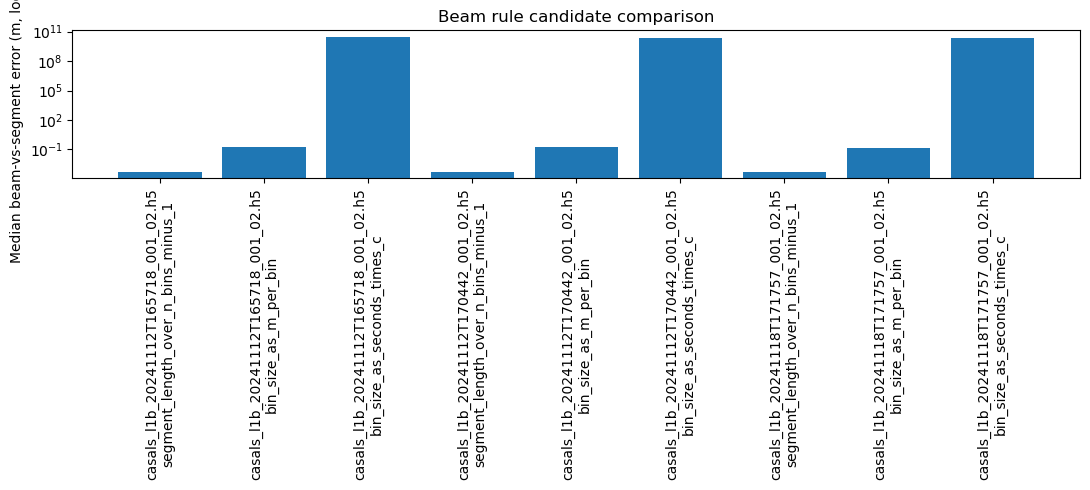

,file,line_source,angle_unit,p90_abs_plane_distance_m,label
0,casals_l1b_20241112T165718_001_02.h5,beam_angle_lines,degree,48.942400,casals_l1b_20241112T165718_001_02.h5\nbeam_ang...
1,casals_l1b_20241112T165718_001_02.h5,beam_angle_lines,radian,0.339238,casals_l1b_20241112T165718_001_02.h5\nbeam_ang...
2,casals_l1b_20241112T165718_001_02.h5,rwstart_rwstop_segment_endpoints,NaN,0.338610,casals_l1b_20241112T165718_001_02.h5\nrwstart_...
3,casals_l1b_20241112T170442_001_02.h5,beam_angle_lines,degree,5.021828,casals_l1b_20241112T170442_001_02.h5\nbeam_ang...
4,casals_l1b_20241112T170442_001_02.h5,beam_angle_lines,radian,0.345244,casals_l1b_20241112T170442_001_02.h5\nbeam_ang...
5,casals_l1b_20241112T170442_001_02.h5,rwstart_rwstop_segment_endpoints,NaN,0.344197,casals_l1b_20241112T170442_001_02.h5\nrwstart_...
6,casals_l1b_20241118T171757_001_02.h5,beam_angle_lines,degree,8.638441,casals_l1b_20241118T171757_001_02.h5\nbeam_ang...
7,casals_l1b_20241118T171757_001_02.h5,beam_angle_lines,radian,0.100445,casals_l1b_20241118T171757_001_02.h5\nbeam_ang...
8,casals_l1b_20241118T171757_001_02.h5,rwstart_rwstop_segment_endpoints,NaN,0.099884,casals_l1b_20241118T171757_001_02.h5\nrwstart_...


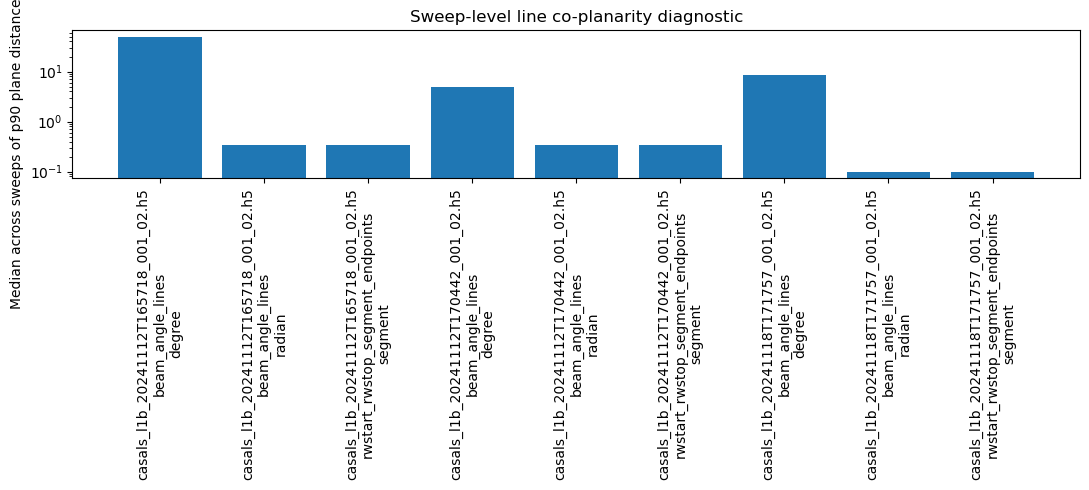

In [ ]:
if len(beam_scores_df):
    plot_df = beam_scores_df.copy()
    plot_df["file"] = plot_df["h5_file"].map(lambda x: Path(x).name)
    # Keep physically meaningful candidates plus the old seconds*c interpretation for contrast.
    keep = plot_df["range_spacing_interpretation"].isin([
        "segment_length_over_n_bins_minus_1",
        "bin_size_as_m_per_bin",
        "bin_size_as_seconds_times_c",
    ]) & (plot_df["angle_unit"] == "radian") & (plot_df["beam_vector_direction"] == "sensor_to_ref")
    small = plot_df[keep].sort_values(["file", "median_beam_vs_segment_disagreement_m"])
    display(small[["file", "beam_rule_key", "median_beam_vs_segment_disagreement_m", "p90_beam_vs_segment_disagreement_m"]])

    plt.figure(figsize=(11, 5))
    labels = small["file"] + "\n" + small["range_spacing_interpretation"]
    x = np.arange(len(small))
    plt.bar(x, small["median_beam_vs_segment_disagreement_m"].to_numpy())
    plt.yscale("log")
    plt.xticks(x, labels, rotation=90)
    plt.ylabel("Median beam-vs-segment error (m, log scale)")
    plt.title("Beam rule candidate comparison")
    plt.tight_layout()
    plt.show()

if len(planarity_df):
    p = planarity_df.copy()
    p["file"] = p["h5_file"].map(lambda x: Path(x).name)
    summary = p.groupby(["file", "line_source", "angle_unit"], dropna=False)["p90_abs_plane_distance_m"].median().reset_index()
    summary["label"] = summary["file"] + "\n" + summary["line_source"] + "\n" + summary["angle_unit"].fillna("segment")
    display(summary)

    plt.figure(figsize=(11, 5))
    x = np.arange(len(summary))
    plt.bar(x, summary["p90_abs_plane_distance_m"].to_numpy())
    plt.yscale("log")
    plt.xticks(x, summary["label"], rotation=90)
    plt.ylabel("Median across sweeps of p90 plane distance (m, log scale)")
    plt.title("Sweep-level line co-planarity diagnostic")
    plt.tight_layout()
    plt.show()


## 9. Interpretation guide

Use the results as follows:

1. If `reference_closure_quality` is strong and `segment_closure_quality` is strong, the L1B file supports **internal** geolocation of arbitrary RX bins by `rwstart/rwstop` interpolation. This is an internal product-consistency statement, not an external accuracy statement.
2. If the best beam rule is `radian|segment_length_over_n_bins_minus_1|sensor_to_ref`, the beam angle direction is consistent with the geolocated range-window segment. This is expected to be the tightest candidate because the spacing comes from the same segment being used as the reference.
3. If the best stored-bin-size beam rule is `radian|bin_size_as_m_per_bin|sensor_to_ref` and its errors are small, then `bin_size` behaves approximately as meters per RX bin for beam propagation. If a seconds-times-c rule produces huge errors, it is a unit misuse, not physical evidence against the beam geometry.
4. Segment closure alone should not be over-interpreted: `rwstart`, `rwstop`, and `refh` may have been generated by the same geolocation model, so the closure can be partly expected by construction.
5. Sweep co-planarity is useful for checking whether a candidate angle convention forms a physically plausible scan plane. It does not prove absolute accuracy and cannot determine range spacing by itself.
6. External validation against 3DEP/NEON/GNSS is still needed for absolute accuracy. The audit here is an internal L1B geometry consistency test.


## 10. Deeper beam-angle convention audit

The earlier beam scoring tested only a small set of angle conventions. This section expands the search over possible local-coordinate definitions:

- angle unit: radians or degrees;
- azimuth zero direction: north or east;
- azimuth positive direction: clockwise or counterclockwise;
- elevation interpretation: elevation from horizon, negative elevation from horizon, zenith angle from up, or nadir angle from down;
- local frame anchor: `refh` or `instrument` location;
- vector sign: as encoded or negated.

The key diagnostic here is direction-only. For each pulse, we compare the candidate beam direction with the stored `rwstart`→`rwstop` segment direction in ECEF. This avoids range-spacing ambiguity and focuses on the coordinate convention.

This is still an internal consistency check because the segment itself comes from L1B geolocation, but it is more targeted than the previous beam propagation test for identifying the angle convention.


In [ ]:

# --- Deeper beam-angle convention search ---
ANGLE_CONVENTION_SAMPLE_PULSES = 200_000  # Increase for final audit if runtime is acceptable.
ANGLE_CONVENTION_TOP_FOR_PROPAGATION = 12

def beam_unit_enu_general(
    az: np.ndarray,
    el: np.ndarray,
    angle_unit: str,
    az_zero_axis: str,
    az_positive: str,
    elevation_mode: str,
    vector_sign: str,
) -> np.ndarray:
    """Return ENU unit vectors under an explicit angle convention."""
    az = np.asarray(az, dtype=float)
    el = np.asarray(el, dtype=float)

    if angle_unit == "degree":
        az = np.deg2rad(az)
        el = np.deg2rad(el)
    elif angle_unit != "radian":
        raise ValueError(angle_unit)

    # Horizontal azimuth convention.
    if az_zero_axis == "north" and az_positive == "clockwise":
        east_h = np.sin(az)
        north_h = np.cos(az)
    elif az_zero_axis == "north" and az_positive == "counterclockwise":
        east_h = -np.sin(az)
        north_h = np.cos(az)
    elif az_zero_axis == "east" and az_positive == "counterclockwise":
        east_h = np.cos(az)
        north_h = np.sin(az)
    elif az_zero_axis == "east" and az_positive == "clockwise":
        east_h = np.cos(az)
        north_h = -np.sin(az)
    else:
        raise ValueError((az_zero_axis, az_positive))

    # Vertical convention.
    if elevation_mode == "elevation_from_horizon":
        horiz = np.cos(el)
        up = np.sin(el)
    elif elevation_mode == "negative_elevation_from_horizon":
        horiz = np.cos(el)
        up = -np.sin(el)
    elif elevation_mode == "zenith_angle_from_up":
        horiz = np.sin(el)
        up = np.cos(el)
    elif elevation_mode == "nadir_angle_from_down":
        horiz = np.sin(el)
        up = -np.cos(el)
    else:
        raise ValueError(elevation_mode)

    vec = np.stack([horiz * east_h, horiz * north_h, up], axis=-1)
    n = np.linalg.norm(vec, axis=1)
    vec = vec / n[:, None]

    if vector_sign == "negated":
        vec = -vec
    elif vector_sign != "as_encoded":
        raise ValueError(vector_sign)
    return vec


def score_angle_conventions_for_file(h5_path: Path) -> pd.DataFrame:
    print("=" * 100)
    print(f"Deep angle-convention audit: {h5_path.name}")

    rows = []
    with h5py.File(h5_path, "r") as h5:
        paths = require_paths(h5)
        n_records = h5[paths["refh"]].shape[0]
        n_sample = min(int(ANGLE_CONVENTION_SAMPLE_PULSES), int(n_records))
        idx = sample_indices(n_records, n_sample, RANDOM_SEED + 701)

        az = read_array(h5, paths, "local_beam_azimuth", idx)
        el = read_array(h5, paths, "local_beam_elevation", idx)

        rwstart_xyz = geodetic_to_ecef(
            read_array(h5, paths, "rwstart_longitude", idx),
            read_array(h5, paths, "rwstart_latitude", idx),
            read_array(h5, paths, "rwstart", idx),
        )
        rwstop_xyz = geodetic_to_ecef(
            read_array(h5, paths, "rwstop_longitude", idx),
            read_array(h5, paths, "rwstop_latitude", idx),
            read_array(h5, paths, "rwstop", idx),
        )
        seg_vec = rwstop_xyz - rwstart_xyz
        seg_norm = np.linalg.norm(seg_vec, axis=1)
        valid = np.isfinite(seg_norm) & (seg_norm > 0)
        seg_unit = np.full_like(seg_vec, np.nan)
        seg_unit[valid] = seg_vec[valid] / seg_norm[valid, None]

        anchor_specs = [
            ("refh", read_array(h5, paths, "refh_longitude", idx), read_array(h5, paths, "refh_latitude", idx)),
        ]
        if "instrument_longitude" in paths and "instrument_latitude" in paths:
            anchor_specs.append((
                "instrument",
                read_array(h5, paths, "instrument_longitude", idx),
                read_array(h5, paths, "instrument_latitude", idx),
            ))

        for anchor_name, anchor_lon, anchor_lat in anchor_specs:
            rot = enu_to_ecef_delta_matrix(anchor_lon, anchor_lat)
            for angle_unit in ["radian", "degree"]:
                for az_zero_axis in ["north", "east"]:
                    for az_positive in ["clockwise", "counterclockwise"]:
                        for elevation_mode in [
                            "elevation_from_horizon",
                            "negative_elevation_from_horizon",
                            "zenith_angle_from_up",
                            "nadir_angle_from_down",
                        ]:
                            for vector_sign in ["as_encoded", "negated"]:
                                try:
                                    u_enu = beam_unit_enu_general(
                                        az=az,
                                        el=el,
                                        angle_unit=angle_unit,
                                        az_zero_axis=az_zero_axis,
                                        az_positive=az_positive,
                                        elevation_mode=elevation_mode,
                                        vector_sign=vector_sign,
                                    )
                                    u_ecef = np.einsum("nij,nj->ni", rot, u_enu)
                                    u_norm = np.linalg.norm(u_ecef, axis=1)
                                    u_ecef = u_ecef / u_norm[:, None]
                                    cosv = np.sum(u_ecef[valid] * seg_unit[valid], axis=1)
                                    cosv = np.clip(cosv, -1.0, 1.0)
                                    angular_error_deg = np.rad2deg(np.arccos(cosv))
                                    rows.append({
                                        "h5_file": str(h5_path),
                                        "anchor": anchor_name,
                                        "angle_unit": angle_unit,
                                        "az_zero_axis": az_zero_axis,
                                        "az_positive": az_positive,
                                        "elevation_mode": elevation_mode,
                                        "vector_sign": vector_sign,
                                        "n_pulses_scored": int(np.sum(valid)),
                                        "median_cosine_to_rwstart_rwstop": float(np.nanmedian(cosv)),
                                        "p10_cosine_to_rwstart_rwstop": float(np.nanpercentile(cosv, 10)),
                                        "median_angular_error_deg": float(np.nanmedian(angular_error_deg)),
                                        "p90_angular_error_deg": float(np.nanpercentile(angular_error_deg, 90)),
                                    })
                                except Exception as e:
                                    rows.append({
                                        "h5_file": str(h5_path),
                                        "anchor": anchor_name,
                                        "angle_unit": angle_unit,
                                        "az_zero_axis": az_zero_axis,
                                        "az_positive": az_positive,
                                        "elevation_mode": elevation_mode,
                                        "vector_sign": vector_sign,
                                        "n_pulses_scored": 0,
                                        "median_cosine_to_rwstart_rwstop": np.nan,
                                        "p10_cosine_to_rwstart_rwstop": np.nan,
                                        "median_angular_error_deg": np.nan,
                                        "p90_angular_error_deg": np.nan,
                                        "error": repr(e),
                                    })

    df = pd.DataFrame(rows)
    df = df.sort_values([
        "median_angular_error_deg",
        "p90_angular_error_deg",
        "median_cosine_to_rwstart_rwstop",
    ], ascending=[True, True, False]).reset_index(drop=True)
    print("Top 10 direction conventions:")
    display(df.head(10))
    return df


angle_convention_df = pd.concat(
    [score_angle_conventions_for_file(p) for p in h5_files],
    ignore_index=True,
)
angle_convention_out = OUT_DIR / "beam_angle_convention_scores.csv"
angle_convention_df.to_csv(angle_convention_out, index=False)
print(f"Wrote: {angle_convention_out}")

print("Best convention per file:")
best_angle_convention_df = angle_convention_df.sort_values([
    "h5_file", "median_angular_error_deg", "p90_angular_error_deg"
]).groupby("h5_file", as_index=False).head(1)
display(best_angle_convention_df)

best_angle_convention_df.to_csv(OUT_DIR / "best_beam_angle_convention.csv", index=False)

# Optional: compare the globally most common top convention.
global_cols = ["anchor", "angle_unit", "az_zero_axis", "az_positive", "elevation_mode", "vector_sign"]
print("Top convention frequency among file winners:")
display(best_angle_convention_df.groupby(global_cols).size().reset_index(name="n_files").sort_values("n_files", ascending=False))


## 11. Export one sweep as a point cloud

This section writes one H5 file / one sweep as a dense point cloud containing **all RX bins** for all available tracks in that sweep.

Output convention:

- coordinates are generated by `rwstart/rwstop` ECEF segment interpolation;
- PLY is always written in a local-meter coordinate frame for easy visualization in CloudCompare/Open3D;
- LAS is written in UTM if `laspy` is installed;
- all waveform-bin points are grayscale by RX amplitude;
- each pulse's `refh` / argmax bin is colored red;
- a small metadata JSON and a `refh` CSV are written for traceability.

The path settings intentionally reuse `L1B_DIR`, `H5_GLOBS`, and `OUT_DIR` from the notebook setup above.


In [ ]:

# --- Export one H5 file / one sweep / all RX bins as point cloud ---
POINTCLOUD_OUT_DIR = OUT_DIR / "pointcloud_exports"
POINTCLOUD_OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_H5_INDEX = 0          # Uses h5_files[EXPORT_H5_INDEX]
EXPORT_SWEEP_NUM = None      # Set an integer sweep number, or None to use the first complete/near-complete sweep.
EXPORT_EVERY_N_BINS = 1      # 1 = all bins. Increase to thin the vertical/range direction.
EXPORT_MIN_TRACKS = 200      # Used only when EXPORT_SWEEP_NUM is None.
EXPORT_WRITE_LAS = True
EXPORT_WRITE_CSV_ALL_POINTS = False  # Full CSV is large; PLY/LAS are preferred.

def choose_export_sweep(h5: h5py.File, paths: dict[str, str], requested_sweep: int | None, min_tracks: int) -> int:
    sweep_num = read_array(h5, paths, "sweep_num", None, dtype=np.int64)
    if requested_sweep is not None:
        return int(requested_sweep)
    unique, counts = np.unique(sweep_num, return_counts=True)
    eligible = unique[counts >= min_tracks]
    if eligible.size == 0:
        # Fall back to the sweep with the maximum number of records.
        return int(unique[np.argmax(counts)])
    # Choose a central eligible sweep to avoid start/end edge effects.
    return int(eligible[len(eligible) // 2])


def write_binary_ply(path: Path, xyz: np.ndarray, rgb: np.ndarray, comments: list[str] | None = None) -> None:
    xyz = np.asarray(xyz, dtype=np.float32)
    rgb = np.asarray(rgb, dtype=np.uint8)
    assert xyz.shape[0] == rgb.shape[0]
    comments = comments or []
    dtype = np.dtype([
        ("x", "<f4"), ("y", "<f4"), ("z", "<f4"),
        ("red", "u1"), ("green", "u1"), ("blue", "u1"),
    ])
    arr = np.empty(xyz.shape[0], dtype=dtype)
    arr["x"], arr["y"], arr["z"] = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    arr["red"], arr["green"], arr["blue"] = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    header = [
        "ply",
        "format binary_little_endian 1.0",
        f"element vertex {xyz.shape[0]}",
        "property float x",
        "property float y",
        "property float z",
        "property uchar red",
        "property uchar green",
        "property uchar blue",
    ]
    for c in comments:
        header.insert(2, f"comment {c}")
    header.append("end_header")
    with open(path, "wb") as f:
        f.write(("\n".join(header) + "\n").encode("ascii"))
        arr.tofile(f)


def export_one_sweep_all_bins_as_pointcloud(h5_path: Path) -> dict[str, object]:
    print("=" * 100)
    print(f"Exporting one sweep point cloud from: {h5_path.name}")
    with h5py.File(h5_path, "r") as h5:
        paths = require_paths(h5)
        rx_ds = h5[paths["rx_waveform"]]
        n_records, n_bins = rx_ds.shape
        sweep_id = choose_export_sweep(h5, paths, EXPORT_SWEEP_NUM, EXPORT_MIN_TRACKS)

        sweep_num = read_array(h5, paths, "sweep_num", None, dtype=np.int64)
        idx = np.where(sweep_num == sweep_id)[0]
        if idx.size == 0:
            raise ValueError(f"No records found for sweep {sweep_id}")

        track = read_array(h5, paths, "track_num", idx, dtype=np.int64) if "track_num" in paths else np.arange(idx.size)
        order = np.argsort(track)
        idx = idx[order]
        track = track[order]

        print(f"Selected sweep_num={sweep_id}, records/tracks={len(idx)}, n_rx_bins={n_bins}, bin step={EXPORT_EVERY_N_BINS}")

        bins = np.arange(0, n_bins, int(EXPORT_EVERY_N_BINS), dtype=np.int32)
        t = bins.astype(float) / float(n_bins - 1)

        p0_llh = np.column_stack([
            read_array(h5, paths, "rwstart_longitude", idx),
            read_array(h5, paths, "rwstart_latitude", idx),
            read_array(h5, paths, "rwstart", idx),
        ])
        p1_llh = np.column_stack([
            read_array(h5, paths, "rwstop_longitude", idx),
            read_array(h5, paths, "rwstop_latitude", idx),
            read_array(h5, paths, "rwstop", idx),
        ])
        p0 = geodetic_to_ecef(p0_llh[:, 0], p0_llh[:, 1], p0_llh[:, 2])
        p1 = geodetic_to_ecef(p1_llh[:, 0], p1_llh[:, 1], p1_llh[:, 2])

        print("Interpolating all bin coordinates in ECEF...")
        xyz_ecef = p0[:, None, :] + t[None, :, None] * (p1 - p0)[:, None, :]
        flat_ecef = xyz_ecef.reshape(-1, 3)

        print("Converting to lon/lat/h...")
        llh = ecef_to_geodetic(flat_ecef)
        lon = llh[:, 0]
        lat = llh[:, 1]
        h = llh[:, 2]

        # Use local ENU-like meter coordinates for PLY by projecting to UTM and subtracting an origin.
        lon0 = float(np.nanmedian(p0_llh[:, 0]))
        lat0 = float(np.nanmedian(p0_llh[:, 1]))
        zone = int(np.floor((lon0 + 180.0) / 6.0) + 1)
        epsg = (32600 if lat0 >= 0 else 32700) + zone
        utm_crs = f"EPSG:{epsg}"
        to_utm = Transformer.from_crs(GEODETIC_CRS, utm_crs, always_xy=True)
        print(f"Projecting to {utm_crs}...")
        x_utm, y_utm, z_utm = to_utm.transform(lon, lat, h)

        origin = np.array([
            float(np.nanmedian(x_utm)),
            float(np.nanmedian(y_utm)),
            float(np.nanmedian(z_utm)),
        ])
        xyz_local = np.column_stack([x_utm, y_utm, z_utm]) - origin[None, :]

        print("Reading waveform amplitudes and assigning colors...")
        rx = np.asarray(rx_ds[idx, :][:, bins], dtype=np.float32)
        amp = rx.reshape(-1)
        lo, hi = np.nanpercentile(amp, [2, 98])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(np.nanmin(amp)), float(np.nanmax(amp))
        gray = np.clip((amp - lo) / max(hi - lo, 1e-6) * 255, 0, 255).astype(np.uint8)
        rgb = np.stack([gray, gray, gray], axis=1)

        ref_t = read_array(h5, paths, "refh_bounce_time_offset", idx)
        start_t = read_array(h5, paths, "rwstart_bounce_time_offset", idx)
        stop_t = read_array(h5, paths, "rwstop_bounce_time_offset", idx)
        ref_bin_float = predict_refh_bin_fraction(ref_t, start_t, stop_t, n_bins)
        argmax_bin = np.argmax(np.asarray(rx_ds[idx, :], dtype=np.float32), axis=1)

        # Mark the bin nearest to refh/argmax in red.
        # If bins were thinned, choose the exported bin nearest to the refh bin.
        ref_export_col = np.array([int(np.argmin(np.abs(bins - b))) for b in ref_bin_float])
        ref_flat_idx = np.arange(len(idx), dtype=np.int64) * len(bins) + ref_export_col
        rgb[ref_flat_idx, :] = np.array([255, 0, 0], dtype=np.uint8)

        stem = f"{h5_path.stem}_sweep_{sweep_id}_all_bins_step_{EXPORT_EVERY_N_BINS}"
        ply_path = POINTCLOUD_OUT_DIR / f"{stem}_local.ply"
        comments = [
            f"source_h5={h5_path}",
            f"sweep_num={sweep_id}",
            f"utm_crs={utm_crs}",
            f"local_origin_utm_x_y_z={origin[0]:.6f},{origin[1]:.6f},{origin[2]:.6f}",
            "coordinates=UTM minus local_origin",
            "colors=grayscale RX amplitude; red=refh/argmax bin per pulse",
        ]
        write_binary_ply(ply_path, xyz_local.astype(np.float32), rgb, comments=comments)
        print(f"Wrote PLY: {ply_path}")

        las_path = None
        if EXPORT_WRITE_LAS:
            try:
                import laspy
                las_path = POINTCLOUD_OUT_DIR / f"{stem}_utm.las"
                las = laspy.create(point_format=3, file_version="1.2")
                las.header.offsets = np.array([np.nanmin(x_utm), np.nanmin(y_utm), np.nanmin(z_utm)])
                las.header.scales = np.array([0.001, 0.001, 0.001])
                las.x = x_utm
                las.y = y_utm
                las.z = z_utm
                las.red = rgb[:, 0].astype(np.uint16) * 257
                las.green = rgb[:, 1].astype(np.uint16) * 257
                las.blue = rgb[:, 2].astype(np.uint16) * 257
                # Use user_data to mark refh points without abusing ASPRS class labels.
                user_data = np.zeros(len(rgb), dtype=np.uint8)
                user_data[ref_flat_idx] = 100
                las.user_data = user_data
                las.write(las_path)
                print(f"Wrote LAS: {las_path}")
            except Exception as e:
                print(f"LAS export skipped or failed: {e}")

        refh_csv_path = POINTCLOUD_OUT_DIR / f"{stem}_refh_points.csv"
        refh_rows = pd.DataFrame({
            "source_record_index": idx,
            "sweep_num": sweep_id,
            "track_num": track,
            "refh_bin_float": ref_bin_float,
            "argmax_bin": argmax_bin,
            "exported_refh_bin": bins[ref_export_col],
            "refh_lon": read_array(h5, paths, "refh_longitude", idx),
            "refh_lat": read_array(h5, paths, "refh_latitude", idx),
            "refh_h": read_array(h5, paths, "refh", idx),
        })
        refh_rows.to_csv(refh_csv_path, index=False)
        print(f"Wrote refh CSV: {refh_csv_path}")

        all_csv_path = None
        if EXPORT_WRITE_CSV_ALL_POINTS:
            all_csv_path = POINTCLOUD_OUT_DIR / f"{stem}_all_points.csv"
            repeated_track = np.repeat(track, len(bins))
            tiled_bins = np.tile(bins, len(idx))
            is_refh = np.zeros(len(tiled_bins), dtype=bool)
            is_refh[ref_flat_idx] = True
            pd.DataFrame({
                "x_utm": x_utm,
                "y_utm": y_utm,
                "z": z_utm,
                "lon": lon,
                "lat": lat,
                "h": h,
                "sweep_num": sweep_id,
                "track_num": repeated_track,
                "rx_bin": tiled_bins,
                "rx_amp": amp,
                "is_refh_bin": is_refh,
            }).to_csv(all_csv_path, index=False)
            print(f"Wrote full CSV: {all_csv_path}")

        meta = {
            "source_h5": str(h5_path),
            "sweep_num": int(sweep_id),
            "n_records": int(len(idx)),
            "n_rx_bins_total": int(n_bins),
            "n_exported_bins_per_record": int(len(bins)),
            "n_exported_points": int(len(rgb)),
            "export_every_n_bins": int(EXPORT_EVERY_N_BINS),
            "utm_crs": utm_crs,
            "local_origin_utm_x_y_z": origin.tolist(),
            "ply_path": str(ply_path),
            "las_path": str(las_path) if las_path is not None else None,
            "refh_csv_path": str(refh_csv_path),
            "all_points_csv_path": str(all_csv_path) if all_csv_path is not None else None,
            "color_rule": "grayscale RX amplitude; red = refh/argmax bin per pulse",
        }
        meta_path = POINTCLOUD_OUT_DIR / f"{stem}_metadata.json"
        meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
        print(f"Wrote metadata: {meta_path}")

        return meta


export_meta = export_one_sweep_all_bins_as_pointcloud(h5_files[EXPORT_H5_INDEX])
display(pd.Series(export_meta))
